# Вариант 4-4

**Калягин Дмитрий, Аверьянова Мария**

**ИАД-25**

--------------------------------------------------------------

## Задача оптимизации
$$f(x) = \frac{p}{2} \Vert Ax - b \Vert ^2 + \sum_{i=1}^m \log \bigg( 2 \cosh \big(u_i^\top (x - a)\big)\bigg),$$


$$
a \in \R^n, b \in \R^m, A \in \R^{m \times n}, u_i \in \R^n, p \ge 0, m=\frac{n}{5} \\
x \in \R^n - переменная~оптимизации, \Vert \cdot \Vert - евклидова~норма
$$

**Введенные ограничения:**
$$
q^\top x \le \eta
$$

In [1]:
import time
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm

np.random.seed(42)

In [2]:
def f_value(x, A, b, a, U, p):
    term1 = (p/2) * np.linalg.norm(A @ x - b)**2
    z = U @ (x - a)
    term2 = np.sum(np.log(2*np.cosh(z)))
    return term1 + term2

In [3]:
def estimate_L(A, U, p):
    M = p * A.T @ A + U.T @ U
    return np.linalg.eigvalsh(M).max()

In [4]:
def generate_problem(n, rng):
    if not rng:
        rng = np.random

    m = max(1, n // 5)
    A = rng.randn(m, n)
    b = rng.randn(m)
    a = rng.randn(n)
    U = rng.randn(m, n)
    p = rng.rand() + 0.1
    q = rng.randn(n)
    eta = abs(rng.randn()) + 0.5

    return A, b, a, U, p, q, eta

In [5]:
def generate_start_points(n, num_points=100):
    return [np.random.randn(n) for _ in range(num_points)]

## Введение ограничения

Учитывая введенное ограничение, при выполнении шага градиента необходимо произвести проекцию обновленного значения вектора на множество $q^\top x \le \eta$

**Что такое проекция на множество**

Проекция точки $x$ на множество $C$ - это точка:

$$
\Pi_C(x) = \arg \underset{y \in C}{\min} \Vert y-x \Vert^2
$$

то есть ближайшая к $x$ точка из допустимого множества.

$$
C = \{ y \mid q^\top y \le \eta \}
$$

Если
$$
q^\top x \gt \eta
$$
то точка вне полупространства.

Нужно найти ближайшую точку - точку на границе, то есть:
$$
q^\top x = \eta
$$

Нужно решить задачу с линейным ограничением:
$$
\begin{cases}
    \underset{y}{\min} \Vert y-x \Vert^2 &\\
    q^\top x = \eta
\end{cases}
$$

Функция Лагранжа (инимизируем по $y$):
$$
L(y,\lambda) = \Vert y-x \Vert ^2 + \lambda (q^\top y - \eta)
$$

Ее градиент:
$$
\nabla_y L = 2(y-x) + \lambda q
$$

Минимум:
$$
2(y-x) + \lambda q  = 0  \\
y = x - \frac{\lambda}{2}q
$$

Подставляем в ограничение:
$$
q^\top \Big( x - \frac{\lambda}{2}q \Big) = \eta
\\
q^\top x = \frac{\lambda}{2} q^\top q = \eta
\\
\lambda = 2 \frac{q^\top x - \eta}{q^\top q}
$$

Подставляем обратно в $y$:
$$
y = x - \frac{q^\top x - \eta}{q^\top q}q
$$

Получаем формулу проекции:
$$
\Pi_{\{q^\top x = \eta\}}(x) = x - \frac{q^\top x - \eta}{\Vert q \Vert ^2}q
$$

Тогда получаем:

$$
\boxed{
    \Pi(x) =
    \begin{cases}
        x, & если \ q^\top \le \eta &\\
        x - \frac{q^\top x - \eta}{\Vert q \Vert ^2} q, & иначе
    \end{cases}
}
$$
где
$$
C = \{ x \mid q^\top y \le \eta \}
$$

In [64]:
def project(x, q, eta):
    if q @ x <= eta:
        return x

    return x - ((q @ x - eta) / (q @ q)) * q

In [65]:
class GradientStrategy:

    def __init__(self, opt):
        self.opt = opt

    def compute(self, x, k):
        raise NotImplementedError

    def step_size(self, k):
        return 1.0 / self.opt.L

## Полный градиент

In [66]:
def gradient(x, A, b, a, U, p):
    g1 = p * A.T @ (A @ x - b)
    z = U @ (x - a)
    g2 = U.T @ np.tanh(z)

    return g1 + g2

In [67]:
class CompleteGradient(GradientStrategy):

    def compute(self, x, k):
        return gradient(
            x,
            self.opt.A,
            self.opt.b,
            self.opt.a,
            self.opt.U,
            self.opt.p,
        )

## Стохастический градиент

Нужно представить
$$
f(x) = \sum_{i=1}^M \phi_i(x)
$$

и вместо полного градиента использовать
$$
g(x^k, \xi^k) = M \nabla \phi_{\xi^k}(x^k)
$$

где
$$
\xi^k \sim \text{Unif}\{1,\dots,M\}
$$

---

Исследуемая функция:
$$
f(x) = \frac{p}{2} \Vert Ax - b \Vert ^2 + \sum_{i=1}^m \log \bigg( 2 \cosh \big(u_i^\top (x - a)\big)\bigg)
$$

Раскроем квадрат:
$$
\Vert Ax-b \Vert ^2 = \sum_{i=1}^m (A_i x - b_i)^2
$$
где $A_i$ - строка $A$.

Получаем:
$$
f(x) = \sum_{i=1}^m \frac{p}{2} (A_i x - b_i)^2 + \sum_{i=1}^m \log \bigg( 2 \cosh \big(u_i^\top (x - a)\big)\bigg)
$$

Видим две суммы по $m$ элементов, тогда в нашем случае $M=m$, значит $\phi_i$:
$$
\phi_i(x) = \frac{p}{2} (A_i x - b_i)^2 + \log \bigg( 2 \cosh \big(u_i^\top (x - a)\big)\bigg)
$$
$$
f(x) = \sum_{i=1}^m \phi_i(x)
$$

---

Проверим градиент:
$$
\nabla \phi_i(x) = p (A_i x - b_i) A_i^\top + \tanh(u_i^\top(x-a)) u_i
$$
Их сумма:
$$
\sum_i \nabla \phi_i = p A^\top (Ax-b) + \sum_{i=1}^{m} \tanh(u_i^\top(x-a)) u_i
$$
то есть градиент полной функции.

Проецируя на алгоритм обновления $x$:
$$
x_{k+1} ​= x_k ​− hg_k​, \quad g_k ​= g(x_k​,\xi_k​) \\
\xi_k \sim \text{Unif}\{1,\dots,M\}
$$


In [68]:
def stochastic_gradient(x, A, b, a, U, p):

    m = A.shape[0]
    i = np.random.randint(m)

    Ai = A[i]
    bi = b[i]
    ui = U[i]

    g1 = p * (Ai @ x - bi) * Ai
    g2 = np.tanh(ui @ (x - a)) * ui

    g = g1 + g2

    return m * g

In [69]:
# class StochasticGradient(GradientStrategy):

#     def compute(self, x, k):
#         return stochastic_gradient(
#             x,
#             self.opt.A,
#             self.opt.b,
#             self.opt.a,
#             self.opt.U,
#             self.opt.p,
#         )
    
class StochasticGradient(GradientStrategy):
    def __init__(self, opt):
        super().__init__(opt)
        self.base_lr = 0.3 / opt.L
        self.prev_lr = self.base_lr
        self.decay_started = False
        self.k_switch = None
        self.lr_switch = None
        self.history = []
        self.window = opt.kwargs.get("window", 20)
        self.plateau_tol = opt.kwargs.get("plateau_tol", 1e-4)

    def compute(self, x, k):
        g = stochastic_gradient(
            x,
            self.opt.A,
            self.opt.b,
            self.opt.a,
            self.opt.U,
            self.opt.p,
        )

        # gradient clipping
        g_norm = np.linalg.norm(g)
        if g_norm > 10:
            g = g * (10 / g_norm)

        # сохраняем историю f(x) для адаптивного lr
        fx = f_value(x, self.opt.A, self.opt.b, self.opt.a, self.opt.U, self.opt.p)
        self.history.append(fx)

        # проверка plateau
        if not self.decay_started and len(self.history) > self.window:
            diffs = [
                abs(self.history[-i] - self.history[-i - 1])
                for i in range(1, self.window)
            ]
            avg_diff = np.mean(diffs)
            if avg_diff < self.plateau_tol:
                self.decay_started = True
                self.k_switch = k
                self.lr_switch = self.prev_lr

        return g

    def step_size(self, k):
        if not self.decay_started:
            lr = self.base_lr
        else:
            lr = self.lr_switch / np.sqrt(k - self.k_switch + 1)
        lr = min(lr, self.prev_lr)
        self.prev_lr = lr
        return lr

## Стохастический градиент + минибатчинг

В отличие от обычного стохастического градиента, вместо одного индекса берём несколько ($b$ - размер батча):
$$
S_k = \{ \xi^k_1, \dots, \xi^k_b \}
$$
где
$$
\xi^k_j \sim \text{Unif}\{1,\dots,M\}
$$

Новый градиент:
$$
g(x^k, \xi^k) \rightarrow \frac{1}{b} \sum_{j \in S^k} g(x^k, \xi_j^k)
$$
то есть мы берём $b$ стохастических градиентов и усредняем.

Подставим $g$ из прошлого пункта:
$$
g(x,\xi_j) = M \nabla \phi_{\xi_j}(x)
$$
$$
g_{batch} = \frac{1}{b} \sum^b_{j=1} M \nabla \phi_{\xi_j}(x)
$$

In [70]:
def stochastic_gradient_batch(
    x,
    A, b, a, U, p,
    batch_size,
):
    g = np.zeros_like(x)
    for _ in range(batch_size):
        g += stochastic_gradient(
            x, A, b, a, U, p
        )
    g /= batch_size

    return g

In [71]:
class StochasticMiniBatchGradient(GradientStrategy):

    def __init__(self, opt):
        super().__init__(opt)
        self.batch_size = opt.kwargs.get("batch_size", 4)

    def compute(self, x, k):
        return stochastic_gradient_batch(
            x,
            self.opt.A,
            self.opt.b,
            self.opt.a,
            self.opt.U,
            self.opt.p,
            self.batch_size,
        )

## Стохастический градиент по правой части функции

Предложим:
$$
g(x, \xi) = p A^\top (Ax-b) + m \tanh(u_\xi^\top (x-a)) u_\xi
$$
где
$$
\xi \sim Unif \{1, \dots, m \}
$$

**Несмещенность**

Нужно показать:
$$
E(g(x,\xi)) = \nabla f(x)
$$

Левая часть не случайная, поэтому:
$$
E(pA^\top(Ax-b)) = pA^\top(Ax-b)
$$

Правая часть:
$$
E(m \tanh(u_\xi^\top(x-a)) u_\xi) = \frac{1}{m} \sum_{i=1}^m m \tanh(u_i^\top(x-a)) u_i
$$
$$
= \sum_{i=1}^m \tanh(u_i^\top(x-a)) u_i
$$

Получаем:
$$
E(g) = pA^\top(Ax-b) + \sum_{i=1}^m \tanh(u_i^\top(x-a)) u_i = \nabla f(x)
$$

$\square$ несмещённость доказана

---

**Ограниченность дисперсии**

Нужно показать что:
$$
E \Vert g(x,\xi) \Vert ^2 \le C
$$

Так как
$$
\vert \tanh(t) \vert \le 1
$$
то 
$$
\Vert \tanh(u_i^\top(x-a)) u_i \Vert \le \Vert u_i \Vert
$$

Значит
$$
\Vert g(x,\xi) \Vert \le \Vert pA^\top(Ax-b) \Vert + m \Vert u_\xi \Vert
$$
Так как матрицы $A$, $U$ фиксированы, существует константа $C$, что
$$
E \Vert g(x,\xi) \Vert ^2 \le C
$$
Следовательно, дисперсия стохастического градиента ограничена.

In [72]:
def stochastic_gradient_new(
    x,
    A, b, a, U, p,
):
    m = A.shape[0]
    i = np.random.randint(m)
    # full quadratic part
    g1 = p * A.T @ (A @ x - b)
    # random cosh part
    ui = U[i]
    g2 = np.tanh(ui @ (x - a)) * ui

    return g1 + m * g2

In [73]:
class StochasticCustomGradient(GradientStrategy):

    def compute(self, x, k):
        return stochastic_gradient_new(
            x,
            self.opt.A,
            self.opt.b,
            self.opt.a,
            self.opt.U,
            self.opt.p,
        )

In [74]:
def stochastic_gradient_new_batch(
    x,
    A, b, a, U, p,
    batch_size,
):
    g = np.zeros_like(x)
    for _ in range(batch_size):
        g += stochastic_gradient_new(
            x, A, b, a, U, p
        )
    g /= batch_size

    return g

In [75]:
class StochasticCustomMiniBatchGradient(GradientStrategy):

    def __init__(self, opt):
        super().__init__(opt)
        self.batch_size = opt.kwargs.get("batch_size", 4)

    def compute(self, x, k):
        return stochastic_gradient_new_batch(
            x,
            self.opt.A,
            self.opt.b,
            self.opt.a,
            self.opt.U,
            self.opt.p,
            self.batch_size,
        )

## Реализация методов градиентного спуска

In [76]:
class BaseOptimizer:
    def __init__(
        self,
        A, b, a, U, p, q, eta,
        grad_type="complete",
        eps=1e-2,
        max_iter=10000,
        **kwargs,
    ):
        self.A = A
        self.b = b
        self.a = a
        self.U = U
        self.p = p
        self.q = q
        self.eta = eta

        self.grad_type = grad_type
        self.eps = eps
        self.max_iter = max_iter

        self.kwargs = kwargs

        self.L = estimate_L(A, U, p)

        self.grad_strategy = self._make_grad_strategy(grad_type)

    # ---------- gradient strategy ----------
    def _make_grad_strategy(self, grad_type):

        if grad_type == "complete":
            return CompleteGradient(self)

        elif grad_type == "stochastic":
            return StochasticGradient(self)

        elif grad_type == "stochastic_mini_batch":
            return StochasticMiniBatchGradient(self)

        elif grad_type == "stochastic_custom":
            return StochasticCustomGradient(self)

        elif grad_type == "stochastic_custom_mini_batch":
            return StochasticCustomMiniBatchGradient(self)

        else:
            raise ValueError(f"Unknown grad_type {grad_type}")

    def grad(self, x, k):
        return self.grad_strategy.compute(x, k)

    def step_size(self, k):
        return self.grad_strategy.step_size(k)

    # ---------- common helpers ----------

    def project(self, x):
        return project(x, self.q, self.eta)

    def f(self, x):
        return f_value(x, self.A, self.b, self.a, self.U, self.p)

    # ---------- main interface ----------

    def solve(self, x0):
        raise NotImplementedError

### Метод линейного каплинга с моментумом

$ y = x - lr \cdot \nabla f(x) $ - градиентный шаг

$ z_{k+1} = z_k + \beta (z_k - z_{k-1}) - \gamma \cdot \nabla f(x) $ - моментум с поправкой на градиент \
Здесь $(z_k - z_{k-1})$ - это скорость сходимости, $\beta$ отвечает за сохранение направления движения, а $(- \gamma \cdot \nabla f(x))$ поправка на градиент

$ x_{k+1} = \tau \cdot z_{k+1} + (1 - \tau) \cdot y $ - каплинг (смешивание) градиентного спуска и моментума с параметром $\tau$

In [77]:
class LinearCoupling(BaseOptimizer):

    def solve(self, x0):

        x = x0.copy()
        z = x0.copy()
        z_prev = x0.copy()

        history = []

        beta = self.kwargs.get("beta", 0.7)
        tau = self.kwargs.get("tau", 0.3)

        for k in range(self.max_iter):

            g = self.grad(x, k)

            lr = self.step_size(k)

            # clipping
            g_norm = np.linalg.norm(g)
            if g_norm > 10:
                g = g * (10 / g_norm)

            y = x - lr * g

            z_new = z + beta * (z - z_prev) - lr * g

            x_new = tau * z_new + (1 - tau) * y

            x_new = self.project(x_new)

            if np.linalg.norm(x_new - x) < self.eps:
                break

            z_prev = z
            z = z_new
            x = x_new

            history.append(self.f(x))

        return x, history

### Метод момента Нестерова

**Константы:**

$h = \frac{1}{L}$ - градиентный шаг оптимизации

$\tau = \frac{\sqrt{L} - \sqrt{\mu}}{\sqrt{L} + \sqrt{\mu}}$ - в нашем случае $\mu = 0$ всегда, поэтому $\tau = 1$ 

**Алгоритм:**

Двигаемся дальше в направлении предыдущего шага:
$$
y_k​ = x_k ​+ \tau ( x_k​ − x_{k−1}​)
$$

Считаем градиент в новой точке:
$$
g_k​ = \nabla f(y_k​)
$$

Двигаемся дальше в направлении антиградиента в новой точке:
$$
x_{k+1} = y_k ​− h \nabla f(y_k​)
$$
точнее в нашем случае с ограничением:
$$
x_{k+1} = \Pi​(y_k ​− hg_k​)
$$

In [83]:
class Nesterov(BaseOptimizer):

    def solve(self, x0):

        x = x0.copy()
        x_prev = x0.copy()

        h = 1.0 / self.L

        history = []

        tau = self.kwargs.get("tau", 1.0)

        for k in range(self.max_iter):

            y = x + tau * (x - x_prev)

            g = self.grad(y, k)

            lr = self.step_size(k)

            x_new = y - lr * g

            x_new = self.project(x_new)

            step_norm = np.linalg.norm(x_new - x)

            history.append(step_norm)

            if step_norm < self.eps:
                break

            x_prev = x
            x = x_new

        return x, history

## Эксперименты

In [84]:
import time
import numpy as np
from tqdm import tqdm


def run_experiment(
    method_class,
    grad: str = "complete",
    eps=1e-2,
    max_iter=10000,
    num_starts=100,
    seed=42,
    method_kwargs: dict = None,
):

    if method_kwargs is None:
        method_kwargs = {}

    rng = np.random.RandomState(seed)

    results = {}

    for n in tqdm(
        range(10, 101, 10),
        desc=f"Running {method_class.__name__}",
    ):

        problem = generate_problem(n, rng)
        A, b, a, U, p, q, eta = problem

        starts = generate_start_points(n, num_starts)

        best_result = None
        best_value = np.inf

        runs_data = []

        for x0 in starts:

            start_time = time.perf_counter()

            opt: BaseOptimizer = method_class(
                A=A,
                b=b,
                a=a,
                U=U,
                p=p,
                q=q,
                eta=eta,
                grad_type=grad,
                eps=eps,
                max_iter=max_iter,
                **method_kwargs,
            )

            out = opt.solve(x0)

            end_time = time.perf_counter()

            if isinstance(out, tuple):
                x_sol = out[0]
                history = out[1] if len(out) > 1 else []
            else:
                x_sol = out
                history = []

            f_val = f_value(x_sol, A, b, a, U, p)

            iters = len(history) if history else None

            runtime = end_time - start_time

            run_info = {
                "x": x_sol,
                "f_value": f_val,
                "iterations": iters,
                "time": runtime,
                "history": history,
            }

            runs_data.append(run_info)

            if f_val < best_value:
                best_value = f_val
                best_result = run_info

        results[n] = {
            "best": best_result,
            "all_runs": runs_data,
        }

    return results

In [ ]:
lc_mom_results = run_experiment(
    LinearCoupling,
    grad="stochastic",
    method_kwargs={"beta": 0.8, "tau": 0.2}
)

Running LinearCoupling:  30%|███       | 3/10 [00:16<00:50,  7.15s/it]

In [81]:
def plot_convergence(results, n_values=None):
    plt.figure()

    if n_values is None:
        n_values = sorted(results.keys())

    for n in n_values:
        history = results[n]["best"]["history"]

        if history:
            plt.plot(history, label=f"n={n}")

    plt.xlabel("Iteration")
    plt.ylabel("f(x)")
    plt.title("Convergence of f(x_k)")
    plt.legend()
    plt.grid()

    plt.show()

In [82]:
plot_convergence(lc_mom_results)

TypeError: tuple indices must be integers or slices, not str

<Figure size 640x480 with 0 Axes>

Уменьшение параметров $\tau$ и $\beta$ приводит к снижению осцилляций и более стабильной сходимости, особенно в присутствии проекционного шага, который нарушает инерционную динамику метода. \
При большом $\beta$ метод “перелетает” минимум \
А при уменьшении $\tau$ больше веса у градиентного шага, чем у momentum, поэтому снижение получается более контролируемым

In [299]:
def plot_scaling(results):
    ns = sorted(results.keys())

    times = []
    iters = []

    for n in ns:
        best = results[n]["best"]
        times.append(best["time"])
        iters.append(best["iterations"])

    # время
    plt.figure()
    plt.plot(ns, times, marker='o')
    plt.xlabel("n")
    plt.ylabel("Time (sec)")
    plt.title("Time vs Dimension")
    plt.grid()
    plt.show()

    # итерации
    plt.figure()
    plt.plot(ns, iters, marker='o')
    plt.xlabel("n")
    plt.ylabel("Iterations")
    plt.title("Iterations vs Dimension")
    plt.grid()
    plt.show()

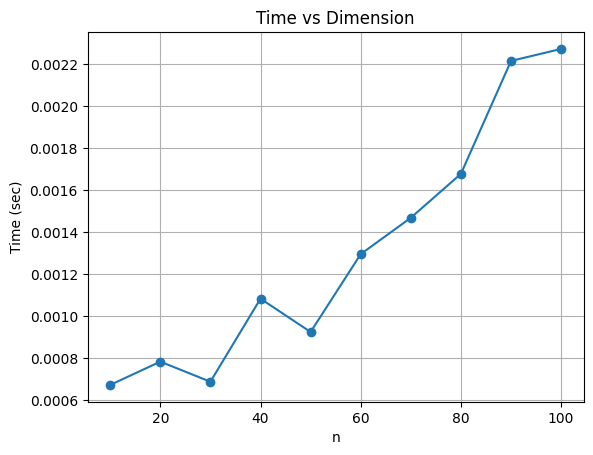

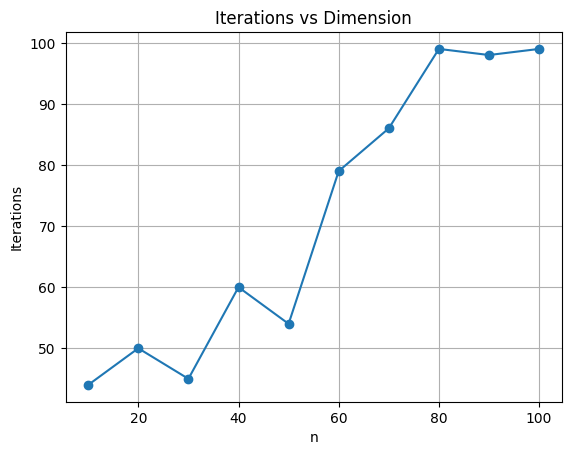

In [300]:
plot_scaling(lc_mom_results)

In [ ]:
lc_mom_sgd_results = run_experiment(linear_coupling_momentum, grad="stochastic")

Running linear_coupling_momentum:  40%|████      | 4/10 [01:07<01:53, 18.86s/it]

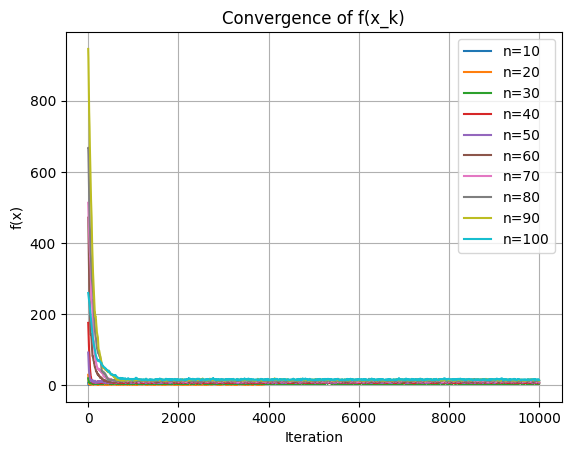

In [ ]:
plot_convergence(lc_mom_sgd_results)

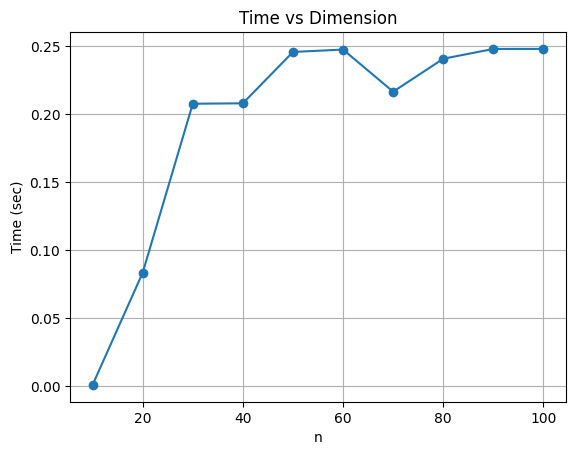

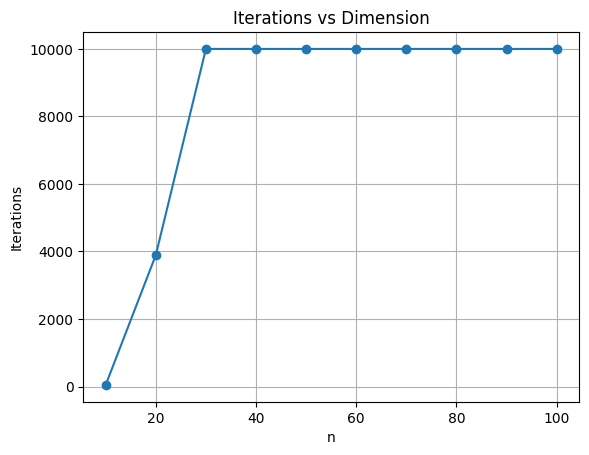

In [ ]:
plot_scaling(lc_mom_sgd_results)